# Configuração do Ambiente Virtual

Siga as instruções abaixo para configurar o ambiente deste notebook:

1. **Execute a célula de código abaixo.** Ela usará o `uv` para criar um ambiente virtual (`.venv`) e instalará as bibliotecas necessárias, incluindo o `ipykernel`.
2. **Execute um Reload Window** (Ctrl+Shift+P → Developer: Reload Window).
3. **Troque o Kernel do Notebook no VS Code:**
   * Após a execução concluir, clique no nome do Kernel atual, no **canto superior direito** da janela do notebook.
   * Escolha **"Select Another Kernel..."** (Selecionar Outro Kernel).
   * Selecione **"Jupyter"**.
   * Escolha o Python que está dentro da pasta `.venv` que acabou de ser criada (ex: `./.venv/bin/python`).
4. **Pronto!** Agora você pode executar as próximas células de análise de dados sem problemas de dependências.

In [1]:
# Instala o uv (caso não esteja instalado no ambiente base)
%pip install uv

# Cria o ambiente virtual (.venv) no diretório atual e força a substituição se já existir
!uv venv --clear

# Instala as bibliotecas e o ipykernel para o VS Code reconhecer o ambiente
!uv pip install pandas numpy matplotlib scikit-learn imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


Using CPython 3.11.9 interpreter at: C:\Users\Yuri Factor\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe
Creating virtual environment at: .venv
Activate with: .venv\Scripts\activate
Resolved 19 packages in 440ms
 Downloaded numpy
 Downloaded pandas
Prepared 6 packages in 10.40s
Installed 19 packages in 3.94s
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.62.1
 + imbalanced-learn==0.14.1
 + joblib==1.5.3
 + kiwisolver==1.5.0
 + matplotlib==3.10.9
 + numpy==2.4.4
 + packaging==26.1
 + pandas==3.0.2
 + pillow==12.2.0
 + pyparsing==3.3.2
 + python-dateutil==2.9.0.post0
 + scikit-learn==1.8.0
 + scipy==1.17.1
 + six==1.17.0
 + sklearn-compat==0.1.5
 + threadpoolctl==3.6.0
 + tzdata==2026.1


In [2]:
!uv pip install ipykernel

Resolved 29 packages in 1.77s
 Downloaded debugpy
 Downloaded pygments
 Downloaded jedi
Prepared 26 packages in 23.59s
Installed 26 packages in 2.60s
 + asttokens==3.0.1
 + colorama==0.4.6
 + comm==0.2.3
 + debugpy==1.8.20
 + decorator==5.2.1
 + executing==2.2.1
 + ipykernel==7.2.0
 + ipython==9.13.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + jupyter-client==8.8.0
 + jupyter-core==5.9.1
 + matplotlib-inline==0.2.1
 + nest-asyncio==1.6.0
 + parso==0.8.6
 + platformdirs==4.9.6
 + prompt-toolkit==3.0.52
 + psutil==7.2.2
 + pure-eval==0.2.3
 + pygments==2.20.0
 + pyzmq==27.1.0
 + stack-data==0.6.3
 + tornado==6.5.5
 + traitlets==5.14.3
 + typing-extensions==4.15.0
 + wcwidth==0.6.0


In [1]:
!uv run python -m ipykernel install --user --name aula-01 --display-name "cursos-eng-dados-titanic(uv)"



Installed kernelspec aula-01 in C:\Users\Yuri Factor\AppData\Roaming\jupyter\kernels\aula-01


# Data Preparation Pipeline for Machine Learning
## Case Study: Titanic Dataset

Etapas:
1. Análise dos Dados (EDA)
2. Limpeza de Dados
3. Tratamento de Outliers
4. Transformações Estatísticas
5. Encoding de Variáveis Categóricas
6. Seleção de Features
7. Split do Dataset e Balanceamento


![imagem](image/pipeline-pre-processamento.jpg)


A imagem divide o pipeline em duas macrofases (Fase 1: Exploração e Saneamento / Fase 2: Engenharia e Estruturação) e abriga os 7 passos descritos da seguinte forma:

Na **Fase 1: Exploração e Saneamento**:

*   A bolha amarela do topo (**EDA e Limpeza Inicial**): Contempla perfeitamente as etapas **1 (Análise dos Dados - EDA)** e **2 (Limpeza de Dados)**. O texto nela diz: "Compreensão visual dos dados seguida da correção de erros e valores ausentes".
*   A bolha verde-água inferior (**Tratamento de Outliers**): Reflete de forma direta a etapa **3 (Tratamento de Outliers)**.

Na **Fase 2: Engenharia e Estruturação**:

*   A engrenagem laranja superior (**Transformações e Encoding**): Agrupa logicamente as etapas **4 (Transformações Estatísticas)** e **5 (Encoding de Variáveis Categóricas)**.
*   A balança vermelha inferior (**Seleção e Split Final**): Sintetiza a etapa **6 (Seleção de Features)** ("Escolha de features relevantes") e engloba perfeitamente a etapa **7 (Split do Dataset e Balanceamento)** ("e balanceamento das classes para o treinamento").

Por fim, a etapa resultante pós-split, é direcionada para a base cilíndrica verde de **"Treinamento"** (onde foi feito o balancemanto indicado pelas bolinhas uniformes) e outra para o **"Teste"**.

In [1]:
# Celula 01
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2

from imblearn.over_sampling import SMOTE

# Carregar Dataset

In [4]:
# Celula 02
df = pd.read_csv('train.csv')
df.head(6)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q


# 1. Análise Exploratória (EDA)

**Observação do Professor:**
Para iniciarmos nossa Análise Exploratória de Dados (EDA), o primeiro passo é sempre entender a estrutura dos dados que temos em mãos.

A função `df.info()` nos fornece um resumo sobre o tamanho do dataset, os tipos de dados de cada coluna e, importantíssimo, a quantidade de valores não-nulos. Ao analisar o retorno dessa função, podemos observar evidências claras de problemas (nulos) em algumas colunas:
- **`Age` (Idade)**: possui 714 valores não-nulos de um total de 891, ou seja, faltam 177 registros. Isso pode ter ocorrido porque as idades não foram integralmente documentadas na época ou algumas informações se perderam no tempo.
- **`Cabin` (Cabine)**: possui apenas 204 valores (faltam quase 77% dos dados). Isso é muito comum pois a maioria dos passageiros (especialmente de classes mais baixas) viajavam em áreas comuns sem cabines exclusivas, ou os registros específicos dessas cabines não chegaram a nós.
- **`Embarked` (Embarque)**: faltam apenas 2 valores. Provavelmente um simples erro de registro humano ou perda da ficha de embarque desses específicos.

In [5]:
# Celula 03
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


**Dicionário de Dados (Significado das Features):**

*   **`0. PassengerId`**: É o número de identificação único de cada passageiro, como se fosse um ID ou matrícula no sistema. Não possui valor analítico real, por isso muitas vezes retiramos essa coluna nos modelos preditivos.
*   **`1. Survived`**: É a nossa *variável alvo* (target). Indica se o passageiro sobreviveu ao naufrágio ou não. (**0** = Não sobreviveu / morreu; **1** = Sobreviveu).
*   **`2. Pclass`**: A classe do bilhete/passagem que o passageiro comprou. É uma indicação de seu status socioeconômico. (**1** = 1ª Classe - alta; **2** = 2ª Classe - média; **3** = 3ª Classe - baixa).
*   **`3. Name`**: O nome completo do passageiro, geralmente incluindo os pronomes de tratamento da época (como Mr., Mrs., Miss, Rev.).
*   **`4. Sex`**: O sexo biológico do passageiro (male = masculino / female = feminino).
*   **`5. Age`**: Idade do passageiro em anos fracionários (ex: 0.42 indica que o bebê tem menos de um ano). *Repare que como tem 714 valores pra um total de 891, sabemos que há dados nulos aqui*.
*   **`6. SibSp`**: Mostra o número de irmãos(ãs) (*siblings*) e/ou cônjuges (*spouses*) que o passageiro em questão tinha a bordo com ele.
*   **`7. Parch`**: Mostra o número de pais/mães (*parents*) e/ou filhos(as) (*children*) que o passageiro tinha a bordo com ele.
*   **`8. Ticket`**: O número formal do bilhete impresso na passagem do cliente.
*   **`9. Fare`**: O valor exato, ou a "Tarifa" paga pela viagem na moeda da época (Libras Esterlinas, possivelmente).
*   **`10. Cabin`**: O número do quarto ou da cabine em que o passageiro foi alocado. *Por conter apenas 204 valores, vemos que a esmagadora maioria está em branco, confirmando a exclusão feita na limpeza*.
*   **`11. Embarked`**: Qual foi o Porto de Embarque em que aquele passageiro subiu no navio Titanic. (**C** = Cherbourg; **Q** = Queenstown; **S** = Southampton).

**Observação do Professor:**
Já a função `df.describe()` gera um sumário estatístico (média, desvio padrão, quartis, valores mínimos e máximos) das colunas numéricas, o que nos ajuda a identificar logo de cara possíveis anomalias numéricas.

Pelo resultado do sumário, vemos coisas interessantes: a idade (`Age`) varia de 0.42 (bebês) a 80 anos. Mas o que mais chama a atenção é a nossa tarifa (`Fare`): a média é 32, a mediana é de apenas 14, mas o valor máximo bate em 512, com um mínimo de 0 (clientes que viajaram de graça ou trabalharam no navio). Essa diferença absurda entre máximo e mediana comprova a forte cauda longa e os grandes desvios que justificaram o nosso tratamento na variável lá na etapa 4!

In [6]:
# Celula 04
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Observação do Professor:**
Como cientistas e engenheiros de dados, sabemos que dados do mundo real quase nunca vêm perfeitos. A função `df.isnull().sum()` nos permite totalizar em números absolutos a quantidade de dados faltantes para podermos traçar um plano de ação (imputar dados ou descartar a coluna).

In [8]:
# Celula 05
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Visualização

**Observação do Professor:**
Aqui nós plotamos os histogramas de todas as features numéricas do dataframe. A análise visual é crucial! Reparem no formato das distributions: a idade (`Age`) parece seguir algo mais próximo de uma distribuição normal, enquanto a tarifa (`Fare`) possui uma clara assimetria à direita. Essas observações visuais guiarão as nossas decisões de processamento estatístico nos próximos passos.

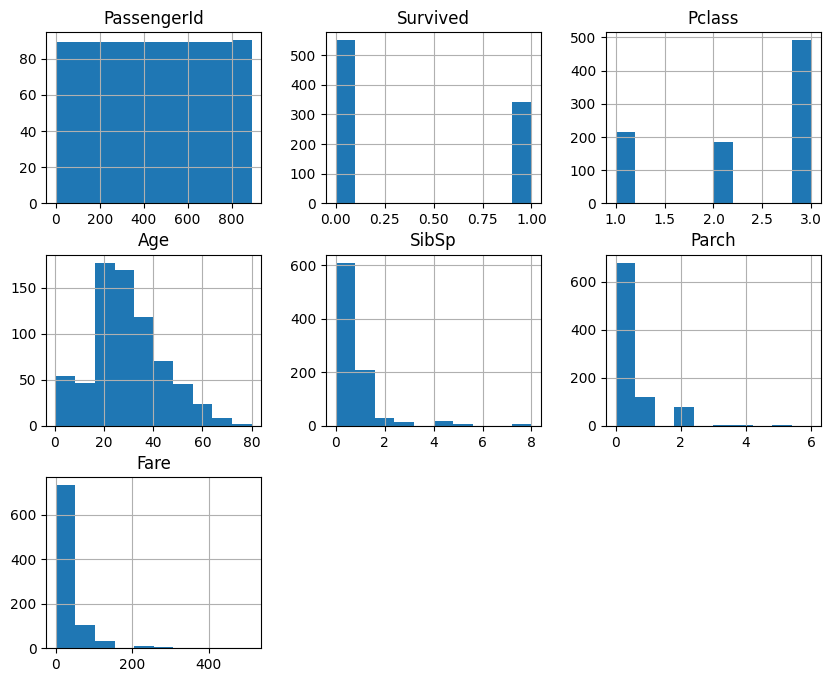

In [9]:
df.hist(figsize=(10,8))
plt.show()

# 2. Limpeza de Dados
### Célula adicionada em 25/03/26
- 'Age' e 'Fare' são as únicas features numéricas contínuas no seu dataset. Temos que tomar cuidado com os dados numéricos contínuos.

- Por exemplo, idades de 150 anos podem ser interpretadas como erros de digitacao e podem ser substituidas pela media ou mediana.

- Porém, idades como 0 e 80 que são consideradas válidas, podem invalidar a predição do algoritmo de ML que dependem de cálculos de distância como o KNN ou SVM. Temos tambem os algoritmos de otimizacao baseada em gradientes como a Regressao Logistica. 

- Todos esses 3 algoritmos seriam impactados pela distância numerica entre esses dados. Por exemplo, imagine uma feature booleana.

- Os valores 0 e 1 possuem uma distância de 1, já na feature Age, podemos ter distâncias muito grandes (80 - 0). 

- Cabe ao cientista reduzir a distância desses dados antes de aplicar um destes algoritmos de ML citados. O atributo 'Fare' (custo da passagem), tambem passa pelo mesmo tipo de solução.

**Observação do Professor:**
Nesta etapa de limpeza, eu comecei removendo as linhas duplicadas para evitar viés no modelo. Em seguida, realizei a imputação dos valores nulos: para a coluna `Age`, utilizei a mediana, que se mostra mais robusta contra valores extremos (outliers) do que a média; para `Embarked`, usei a moda (valor mais frequente). Por fim, removi a coluna `Cabin`, pois, como visto na exploração inicial, ela possui cerca de 77% de valores nulos, o que a torna inviável para o modelo neste cenário.

In [10]:
# Celula 06 - Observe que age possui 613 registros e Cabin 114.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [11]:
# Celula 07 - Observe que após a execucao deste comando, nenhuma linha foi eliminada, pois nao ha linhas duplicadas. 
df = df.drop_duplicates() # Elimina linhas duplicadas
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [12]:
# Celula 08 - Remove valores nulos detectados em Age (714 registros) e Embarked (889 registros). A coluna Cabin será dropada (204 registros)
df['Age'] = df['Age'].fillna(df['Age'].median())                  # utilizei a mediana para substituir os valores nulos
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])  # utilizei a moda para substituir os valores nulos
df = df.drop(columns=['Cabin'])                                   # removi a coluna 'Cabin'

In [15]:
# Celula 09 - Observe que as features Age e Embarked sinalizam 891 registros nao nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


**Observação do Professor - Por que Moda e Mediana?**

O motivo de usarmos medidas estatísticas diferentes se deve à natureza dos dados (o tipo da variável) de cada coluna.

Em Ciência de Dados, a forma como tratamos os números é diferente da forma como tratamos categorias (textos). Vamos entender cada caso:

**1. Embarked (Porto de Embarque) = Variável Categórica**
A coluna Embarked contém texto, representando as categorias dos portos: 'S' (Southampton), 'C' (Cherbourg) e 'Q' (Queenstown).

- **Por que a Moda?** A moda representa o valor que mais se repete. Como não é possível calcular a média ou a mediana de letras/textos (não exite o valor "médio" entre 'S' e 'C'), a moda é a única medida de tendência central aplicável a dados categóricos.
- **A lógica:** Ao usar a moda, estamos basicamente dizendo: "Se não sabemos onde essa pessoa embarcou, vamos chutar que ela embarcou no porto de onde a esmagadora maioria das pessoas embarcou".

**2. Age (Idade) = Variável Numérica (Contínua)**
A coluna Age contém números (ex: 22.0, 38.0, 0.42). Para dados numéricos, a moda costuma ser uma escolha ruim, pois em variáveis contínuas os valores raramente se repetem o suficiente para que a moda represente de fato o "centro" dos dados. Sobram duas opções principais: a Média e a Mediana.

- **Por que a Mediana e não a Média?** A média é muito sensível a outliers (valores atípicos). Se tivermos muitos bebês no navio, ou alguns passageiros muito idosos (80 anos, como vimos no seu `describe()`), a média será "puxada" para cima ou para baixo, distorcendo a realidade. A mediana, por ser o valor exatamente do meio (quando os dados estão ordenados do menor para o maior), ignora os extremos e nos dá um retrato muito mais fiel da idade típica do passageiro do Titanic.

💡 **Resumo da Regra de Ouro na imputação de Nulos:**
- **Dados Numéricos (sem muitos outliers):** Média.
- **Dados Numéricos (com outliers ou distorcidos):** Mediana (geralmente a opção mais segura).
- **Dados Categóricos (Textos/Classes):** Moda.

# 3. Tratamento de Outliers

**Observação do Professor - Tratamento de Outliers (Método IQR):**

Como visualizamos lá em cima no histograma de `Fare` e nos dados numéricos da função `describe()`, a nossa Tarifa possuía alguns valores absurdamente altos em comparação à imensa maioria, criando o que chamamos de uma distribuição com cauda-longa à direita.

Para tratá-la matematicamente de forma correta sem ser por "chute", nós adotamos o consagrado Método **IQR (Intervalo Interquartil)**, a mesma matemática que rege os famosos gráficos de *Boxplot*.
- Primeiro, descobrimos quem dita os valores dos decisivos Quartil 1 (25%) e Quartil 3 (75%). 
- A diferença entre eles gera o Intervalo (o IQR).
- As "cercas" (bounds/limites aceitáveis) para excluir o que é bizarro são estipuladas com um limite máximo para cima e para baixo de `1.5 * IQR`.

Tudo que furar essa cerca (upper/lower), consideramos erro/outlier! E no código da próxima célula, com a linha `df = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]`, nós atualizamos o nosso banco de dados, excluindo estes ruídos mantendo apenas quem teve as finanças localizadas no miolo desta "cerca", que concentra cerca de 99,3% dos dados quando lidamos com distributions normais.

![Tratamento de Outliers (IQR)](image/outliers.jpg)

In [16]:
# Celula 10 - Vamos começar a tratar o primeiro valor continuo que temos: 'Fare'(valor do ticket). 
#             Volte na celula 04 e observe os valores min e max de 'Fare'. 
#             Eles são outliers e como tal, vamos detecta-los  e elimina-los atraves do IQR.

Q1 = df['Fare'].quantile(0.25) # calcula o primeiro quartil
Q3 = df['Fare'].quantile(0.75) # calcula o terceiro quartil

IQR = Q3 - Q1 

lower = Q1 - 1.5 * IQR # margem de tolerância
upper = Q3 + 1.5 * IQR # margem de tolerância

# selecionar os dados que serão removidos (outliers)
outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)] # codigo didático, não precisa manter no notebook
print("Dados que serão REMOVIDOS (outliers):")             # codigo didático, não precisa manter no notebook 
print(outliers[['Fare']])                                  # codigo didático, não precisa manter no notebook

# mantêm apenas os dados que não são outliers
df = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]     # essa linha voce deve manter
print("Dados que permanecem:")
print(df[['Fare']])

Dados que serão REMOVIDOS (outliers):
         Fare
1     71.2833
27   263.0000
31   146.5208
34    82.1708
52    76.7292
..        ...
846   69.5500
849   89.1042
856  164.8667
863   69.5500
879   83.1583

[116 rows x 1 columns]
Dados que permanecem:
        Fare
0     7.2500
2     7.9250
3    53.1000
4     8.0500
5     8.4583
..       ...
886  13.0000
887  30.0000
888  23.4500
889  30.0000
890   7.7500

[775 rows x 1 columns]


In [18]:
# Celula 11 - Observe que ficamos com 775 registros
df.info()

<class 'pandas.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  775 non-null    int64  
 1   Survived     775 non-null    int64  
 2   Pclass       775 non-null    int64  
 3   Name         775 non-null    str    
 4   Sex          775 non-null    str    
 5   Age          775 non-null    float64
 6   SibSp        775 non-null    int64  
 7   Parch        775 non-null    int64  
 8   Ticket       775 non-null    str    
 9   Fare         775 non-null    float64
 10  Embarked     775 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 72.7 KB


# 4. Transformações Estatísticas

**Observação do Professor:**
Aqui nas transformações, eu apliquei inicialmente a transformação logarítmica (`np.log1p`) na coluna de tarifa (`Fare`). Fiz isso pois variáveis monetárias frequentemente apresentam uma forte assimetria à direita (uma cauda longa com valores extremos), e essa transformação ajuda a normalizar a distribuição dos dados.

**O "Poder Mágico" do Logaritmo:**
A função principal do logaritmo na estatística é ser um compressor de diferenças grandes. Ele encurta a distância física entre os números astronômicos, sem alterar a ordem das variáveis (quem for o mais rico continuará sendo o mais rico, porém a discrepância quantitativa será "espremida").

Exemplo prático de compressão: (Lembrete numérico na base 10, apenas para fins lúdicos de sala de aula, enquanto o NumPy utiliza base logaritmo natural por baixo dos panos)

Caso tivéssemos 3 passageiros pagando: 10 ... 100 ... e 1000.

Distância sem usar Log: Entre 10 e 1000 a distância pura num gráfico é enorme! (1000 - 10 = diferença de 990).
A mágica do Log: log10(10) = 1 | log10(100) = 2 | log10(1000) = 3
Conclusão: Após o Log, os exatos mesmos valores se transformaram numa nova coluna onde valem na escala da máquina: 1 ... 2 ... e 3.
Pronto! Nós pegamos uma série de preços com um pico astronômico e a forçamos a assumir o desenho de um comportamento mais suave, próximo de uma distribuição da curva de sino. E aí sim o aprendizado de máquina funciona da melhor forma!

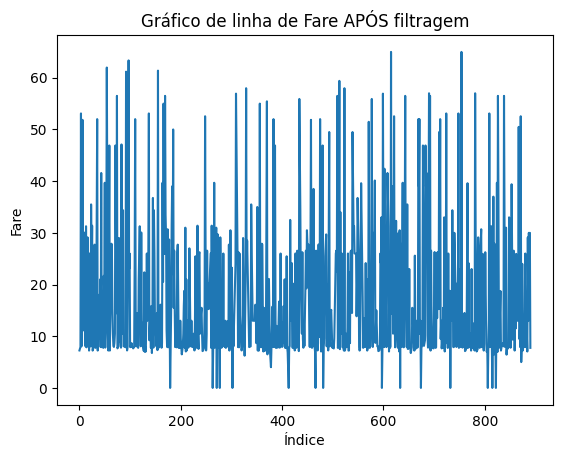

In [19]:
# Celula 12 - Apos a retirada dos outilers de Fare, vamos plotar os valores
#             Observamos abaixo que os valores possuem uma amplitude muito grande: (0.0 a ~60.0)
#             Como analisado em '2. Limpeza de Dados', aprendemos que dados continuos nao podem ter uma amplitude tao alta.
plt.plot(df['Fare'])
plt.title("Gráfico de linha de Fare APÓS filtragem")
plt.xlabel("Índice")
plt.ylabel("Fare")
plt.show()

In [20]:
# Celula 13 - Para reduzir a amplitude, vamos aplicar log1p em Fare, criando uma coluna extra chamada Fare_log.
df['Fare_log'] = np.log1p(df['Fare'])
print(df['Fare_log'])

0      2.110213
2      2.188856
3      3.990834
4      2.202765
5      2.246893
         ...   
886    2.639057
887    3.433987
888    3.196630
889    3.433987
890    2.169054
Name: Fare_log, Length: 775, dtype: float64


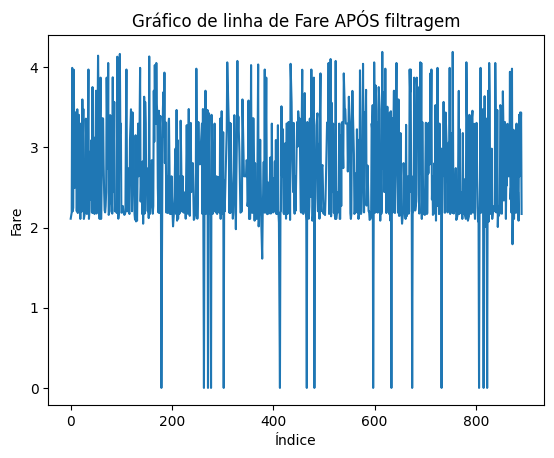

In [21]:
# Celula 14 - Observe agora os dados de Fare_log. Veja que a amplitude baixou para 4 (4-0).
plt.plot(df['Fare_log'])
plt.title("Gráfico de linha de Fare APÓS filtragem")
plt.xlabel("Índice")
plt.ylabel("Fare")
plt.show()

**Observação do Professor:**

Logo após, com o auxílio do `StandardScaler`, eu padronizei as features contínuas. Colocá-las na mesma escala (com média 0 e desvio padrão 1) é fundamental para garantir a performance e a convergência de muitos algoritmos de Machine Learning.

In [22]:
# Celula 15 - StandardScaler: Seu propósito fundamental é transformar a distribuição dos dados 
#                             para que eles tenham uma média de 0 e um desvio padrão de 1. 
#                             Ele faz isso subtraindo a média da feature e dividindo pelo desvio padrão.
#                             Apesar da mudança na amplitude, o StandardScaler é extremamente benéfico 
#                             porque ele garante que todas as features numéricas 
#                             tenham uma escala comparável (média 0, desvio padrão 1).
scaler = StandardScaler()
df[['Age','Fare_log']] = scaler.fit_transform(df[['Age','Fare_log']])

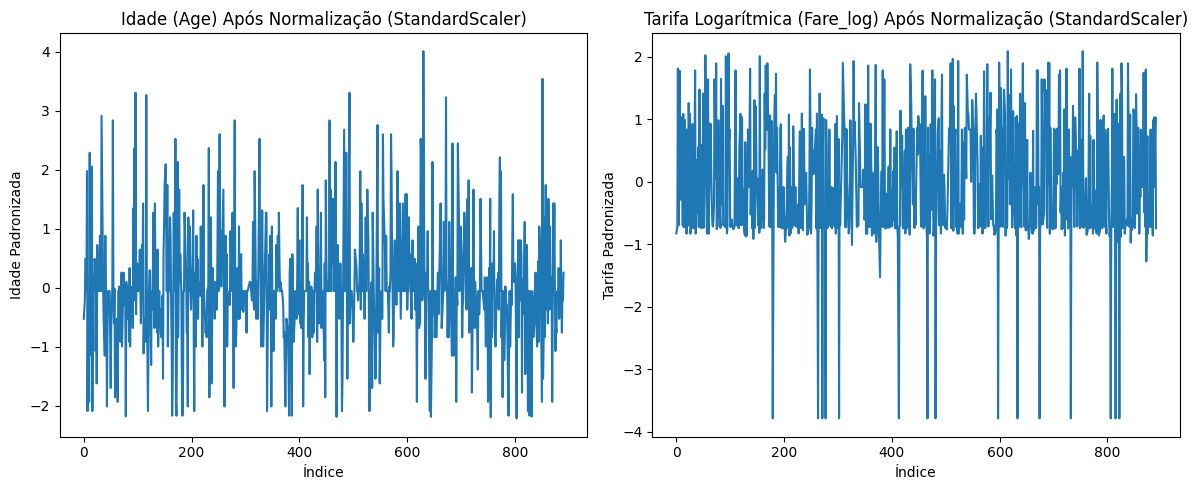

In [24]:
# Celula 16 - Apresenta Age e Fare normalizados!
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(df['Age'])
plt.title("Idade (Age) Após Normalização (StandardScaler)")
plt.xlabel("Índice")
plt.ylabel("Idade Padronizada")

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(df['Fare_log'])
plt.title("Tarifa Logarítmica (Fare_log) Após Normalização (StandardScaler)")
plt.xlabel("Índice")
plt.ylabel("Tarifa Padronizada")

plt.tight_layout()
plt.show()

# 5. Encoding

**Observação do Professor:**
Nesta célula, eu utilizei a técnica de One-Hot Encoding por meio da função `pd.get_dummies`. Observem o uso do parâmetro `drop_first=True`. Eu o implementei como uma boa prática para evitar a chamada 'armadilha da variável dummy' (quando há multicolinearidade perfeita entre os atributos criados), prevenindo impactos negativos, especialmente em modelos descritivos e lineares.

In [25]:
# Celula 17 - pd.get_dummies(): Esta é uma função do pandas usada para converter variáveis 
#             categóricas (como 'Sex' e 'Embarked', que contêm texto ou categorias) em um 
#             formato numérico que os algoritmos de Machine Learning podem entender e processar.
df = pd.get_dummies(df, columns=['Sex','Embarked'], drop_first=True)

In [26]:
# Celula 18 - Para visualizar as colunas Sex e Embarked após a transformação de One-Hot Encoding, 
#             vou exibir as primeiras linhas do DataFrame df, focando nas novas colunas criadas: Sex_male, Embarked_Q e Embarked_S. 
#             Lembre-se que as colunas originais 'Sex' e 'Embarked' foram removidas
#             Os nomes de colunas (Sex_male, Embarked_Q, Embarked_S) são criados automaticamente pela função pd.get_dummies().
print("Colunas Sex_male, Embarked_Q e Embarked_S após One-Hot Encoding:")
display(df[['Sex_male', 'Embarked_Q', 'Embarked_S']].head())

Colunas Sex_male, Embarked_Q e Embarked_S após One-Hot Encoding:


,Sex_male,Embarked_Q,Embarked_S
0,True,False,True
2,False,False,True
3,False,False,True
4,True,False,True
5,True,True,False


In [27]:
# Celula 19 - Observe que ficamos com 775 registros
# Sex_male: Indica se o passageiro é do sexo masculino (True) ou feminino (False). 
#           A coluna Sex_female foi descartada por causa do drop_first=True.
# Embarked_Q: Indica se o passageiro embarcou em Queenstown (True) ou não (False).
# Embarked_S: Indica se o passageiro embarcou em Southampton (True) ou não (False).
# Se ambas Embarked_Q e Embarked_S forem False, isso implica que o passageiro embarcou em Cherbourg ('C'), 
# que foi a categoria descartada. 
# Agora, essas features estão prontas para serem utilizadas por modelos de Machine Learning.

df.info()

<class 'pandas.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  775 non-null    int64  
 1   Survived     775 non-null    int64  
 2   Pclass       775 non-null    int64  
 3   Name         775 non-null    str    
 4   Age          775 non-null    float64
 5   SibSp        775 non-null    int64  
 6   Parch        775 non-null    int64  
 7   Ticket       775 non-null    str    
 8   Fare         775 non-null    float64
 9   Fare_log     775 non-null    float64
 10  Sex_male     775 non-null    bool   
 11  Embarked_Q   775 non-null    bool   
 12  Embarked_S   775 non-null    bool   
dtypes: bool(3), float64(3), int64(5), str(2)
memory usage: 68.9 KB


# 6. Seleção de Features

**Observação do Professor:**
Selecao de Features

In [33]:
X = df.drop(columns=['Survived','Name','Ticket','PassengerId','Fare'])
y = df['Survived']

# 7. Split do Dataset

**Observação do Professor:**

é um dos passos mais importantes de qualquer projeto de Machine Learning: a Divisão de Treino e Teste.

Imagine o seu modelo como um estudante se preparando para o vestibular:

Ele precisa de material para estudar em casa (Treino).
Ele precisa fazer uma prova final com questões inéditas para provar que realmente aprendeu, e não apenas decorou as respostas (Teste).
É extamente isso que a função train_test_split faz. Vamos quebrar a linha pedaço por pedaço:

**1**. Os "Ingredientes" (o que está dentro dos parênteses)

X[selected_features]: São as suas colunas de dados do Titanic (idade, sexo, classe, etc). Ele está pegando apenas as colunas que foram selecionadas como as melhores no passo anterior.

y: É a sua coluna alvo (a resposta do gabarito: sobreviveu ou não).
test_size=0.2: É a proporção da divisão. 0.2 significa 20%. Ou seja, você está separando 20% dos passageiros para a prova final (Teste) e deixando 80% para o modelo estudar (Treino).

random_state=42: O computador escolhe esses 20% e 80% de forma aleatória (por meio de um sorteio). O número 42 funciona como uma "semente" para o sorteio. Ele garante que amanhã, se você rodar essa célula de novo, o computador sorteará exatamente os mesmos passageiros para treino e para teste. Podia ser número 1, número 100, tanto faz.

**2**. O Resultado (o que está antes do sinal de igual =)
A função pega todos os dados, faz o sorteio 80/20 e te devolve 4 novos pedaços de dados:

- X_train (80% das características): O caderno de estudos do modelo.
- y_train (80% das respostas): O gabarito que o modelo olha enquanto estuda o X_train.
- X_test (20% das características): A prova final. Você vai entregar isso pro modelo cego e pedir "quem você acha que sobreviveu aqui?".
- y_test (20% das respostas): O gabarito oficial da prova final que fica guardado a sete chaves com você. 

Você vai usá-lo depois para comparar com as respostas que o modelo te der e calcular a nota (precisão/accuracy) dele!

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Balanceamento com SMOTE

Usar o SMOTE é, por definição, alterar a realidade natural dos dados.

No mundo real, as mortes no Titanic foram a regra (a grande maioria), e as sobrevivências foram a exceção. Quando usamos o SMOTE e forçamos um empate (50/50), estamos criando um cenário artificial que nunca existiu.

Então, por que fazemos isso?

1. Modelos de Machine Learning são "preguiçosos"
Imagine que você crie um modelo para detectar uma doença muito rara que afeta 1 em cada 1.000 pessoas. Se o modelo simplesmente disser "ninguém tem a doença", ele vai acertar 999 vezes e errar 1. A precisão dele será de 99,9%.

Matematicamente o modelo está brilhante, mas para o médico ele é inútil, pois o objetivo era justamente encontrar aquela 1 pessoa doente. Como a doença é rara (não é natural ver muitos casos), o modelo ignorou o padrão dela. O SMOTE cria "pacientes artificiais" para forçar o modelo a prestar atenção neles.

2. O Treino é a "Sala de Aula", não a "Vida Real"
O objetivo da base de treino (X_train) não é refletir perfeitamente a população real, mas sim ser um ambiente controlado onde o modelo possa aprender os padrões numéricos de ambas as classes. Ao ver 50% de sobreviventes e 50% de mortos, o modelo é forçado a entender exatamente o que diferencia um grupo do outro.

A Regra de Ouro do SMOTE:
Como o SMOTE cria um ambiente artificial, existe uma regra sagrada em Ciência de Dados: 👉 Você SÓ PODE aplicar o SMOTE nos dados de Treino (X_train).

Você nunca (sob nenhuma hipótese) aplica o SMOTE nos dados de Teste (X_test). O X_test é a prova final do modelo. Essa prova precisa refletir 100% a natureza desbalanceada e cruel do mundo real para vermos se o modelo realmente aprendeu a identificar os sobreviventes quando eles são minoria.

Existe alternativa?
Sim! Se você não gosta da ideia de criar dados artificiais, a alternativa mais comum é o Peso de Classe (class_weight='balanced'). Em vez de inventar dados sintéticos, você diz ao modelo: "Os sobreviventes são poucos, então se você errar a previsão de um sobrevivente, eu vou te dar uma multa matemática 3 vezes maior do que se você errar a previsão de alguém que morreu".

As duas técnicas têm o mesmo objetivo: forçar o modelo a levar os sobreviventes a sério!

In [36]:
# Celula 22-  Se você subtrair 834 - 620, vai descobrir que a diferença é 214.

# Isso significa que o ambiente artificial do SMOTE inventou exatos 214 "falsos passageiros sobreviventes". 
# Ele pegou os 203 sobreviventes reais, estudou o perfil deles, misturou as características e gerou 214 sintéticos parecidos com eles.

# Agora, o seu X_train_balanced possui exatos 417 passageiros que morreram e 417 passageiros que sobreviveram (totalizando os 834). 
# Um empate perfeito de 50/50 para o modelo estudar!

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(X_train.shape)
print(X_train_balanced.shape)

(620, 8)
(834, 8)


# Machine Learning (Proxima aula)

1. Escolher e Treinar o Modelo (A Sala de Aula)

2. Fase de Teste (A Prova Final)

3. Avaliar as Notas (Métricas de Desempenho)
